<a href='https://www.darshan.ac.in/'> <img src='https://www.darshan.ac.in/Content/media/DU_Logo.svg' width="250" height="300"/></a>
<pre>
<center><b><h1>Machine Learning - 2301CS621</b></center>

<center><b><h1>Lab - 12 </b></center>
<pre>    

# Step 1: Import Libraries

In [5]:
from sklearn.datasets import make_blobs,make_moons
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors

# Step 2: Generate dummy data using make_blobs

In [7]:
x, y = make_blobs(n_samples=10, random_state=42, cluster_std=1)
print(x)
print(y)

[[-5.41397842 -7.10588589]
 [-7.42400992 -6.769187  ]
 [ 3.62704772  2.28741702]
 [-6.81209899 -8.30485778]
 [-2.26723535  7.10100588]
 [-2.97867201  9.55684617]
 [-0.92998481  9.78172086]
 [ 2.914961    1.41088215]
 [ 3.73185476  0.56086598]
 [-2.97261532  8.54855637]]
[2 2 1 2 0 0 0 1 1 0]


# Step 3: Plot Generated data 

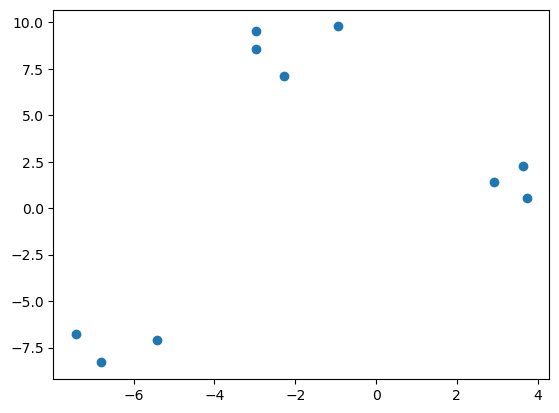

In [8]:
plt.scatter(x[::,0],x[::,1])
plt.show()

# Step 4: Apply Hierarchical Clustering

In [9]:
from sklearn.cluster import AgglomerativeClustering

In [11]:
model = AgglomerativeClustering(n_clusters=4)

In [12]:
y_pred = model.fit_predict(x)

In [13]:
y_pred

array([1, 1, 2, 1, 0, 0, 3, 2, 2, 0])

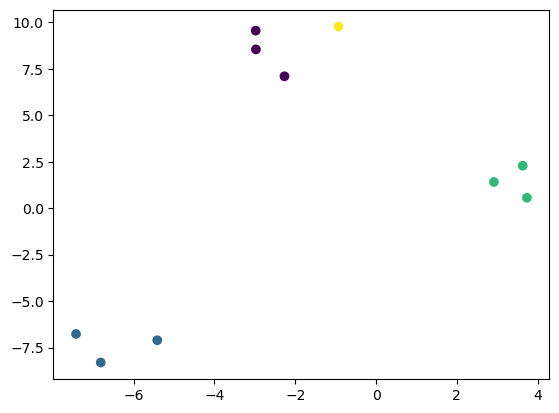

In [16]:
plt.scatter(x[:,0], x[:,1], c=y_pred)
plt.show()

# Step 5: Display Dendrogram

In [20]:
from scipy.cluster.hierarchy import dendrogram, linkage

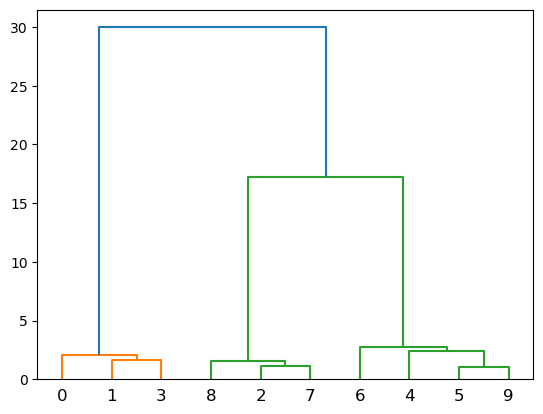

In [21]:
linked = linkage(x,method='ward')
dendrogram(linked)
plt.show()

# Step 6: Generate dummy data using make_moons

In [22]:
x,y = make_moons(n_samples=300, noise=0.09, random_state=50)
x = StandardScaler().fit_transform(x)

# Step 7: Plot Generated data

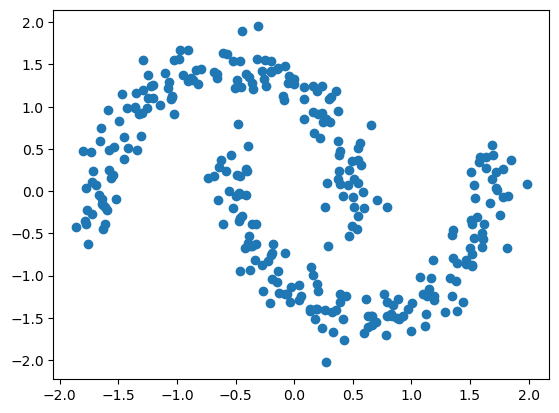

In [23]:
plt.scatter(x[:,0], x[:,1])
plt.show()

# Step 8: apply DBSCAN Clustering 

In [24]:
from sklearn.cluster import DBSCAN

In [25]:
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_pred = dbscan.fit_predict(x)

In [26]:
dbscan_pred

array([ 0,  1,  0,  0,  1,  1,  1,  0,  1,  1,  1,  2,  2,  1,  0,  0,  1,
        0,  0,  1,  1,  1,  3,  3,  0, -1,  1,  4,  0,  1,  1,  1,  1,  3,
        1,  1,  0,  0,  2,  0,  0,  3,  0,  3, -1,  0,  1,  0,  0,  1,  1,
        3,  3,  2, -1,  1,  1,  0,  0,  0,  2,  1,  1,  0,  0,  1,  1,  0,
        1,  0, -1,  1,  1,  3,  0,  0, -1,  0,  1,  1,  0, -1,  4,  1,  0,
        3,  1,  1,  1,  0,  0,  4,  2,  1,  0,  0,  4,  0,  4,  1,  1,  0,
        0,  1,  1,  1,  1,  0,  0,  2,  0,  4,  0,  3,  0,  0,  0, -1,  0,
        1,  0,  1,  1,  0,  4,  2,  0,  1,  0,  1,  1,  0,  3,  0,  0,  1,
        0,  1,  2,  0,  0,  4,  4,  0,  4,  0,  3,  1,  1,  3,  0,  1,  1,
        0,  0,  1,  1, -1,  0,  0,  4,  1,  0,  1,  0, -1,  1,  3,  0,  1,
        0,  0,  1,  0,  4,  3,  2,  4,  0, -1,  0,  3,  1,  2,  0,  0,  3,
        1,  0,  0,  3,  4,  3,  1,  1,  1,  2,  1,  0,  1,  1,  0,  0,  3,
        1,  0,  0,  0,  1,  3,  1,  0,  0,  0,  1,  1,  0,  0,  0,  1,  3,
        1,  1,  1,  0,  1

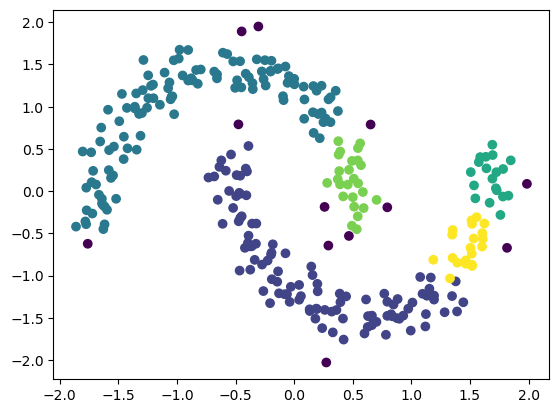

In [28]:
plt.scatter(x[:,0], x[:,1], c=dbscan_pred)
plt.show()

# Step 9: apply K Mean Clustering on same data

In [27]:
from sklearn.cluster import KMeans

In [32]:
kmean = KMeans(n_clusters=5, random_state=42)

In [35]:
kmean_pred = kmean.fit_predict(x)
kmean_pred
centerdata = kmean.cluster_centers_

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


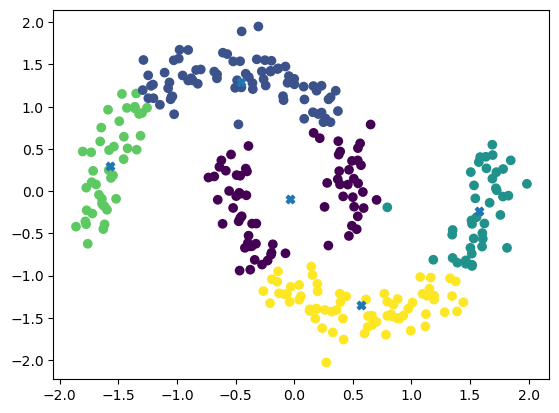

In [36]:
plt.scatter(x[:,0], x[:,1], c=kmean_pred)
plt.scatter(centerdata[:,0], centerdata[:,1], marker='X')
plt.show()

# Mall Customers Segmentation using DBSCAN

### Perform Following steps on Dataset for  customer segmentation
-> Load & Explore the Dataset <br>
-> Data Preprocessing <br>
-> Apply DBSCAN <br>
-> Visualizing Customer Segments <br>
-> Outliers (high-spending VIP customers or unusual shoppers <br>

In [37]:
df = pd.read_csv('Mall_Customers.csv')
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [38]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [39]:
features = ['Annual Income (k$)', 'Spending Score (1-100)']
x = df[features]

In [43]:
df['gender_'] = df['Gender'].map({'Female':0,'Male':1})

In [44]:
df

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),gender_
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,0
3,4,Female,23,16,77,0
4,5,Female,31,17,40,0
...,...,...,...,...,...,...
195,196,Female,35,120,79,0
196,197,Female,45,126,28,0
197,198,Male,32,126,74,1
198,199,Male,32,137,18,1


In [45]:
scaler = StandardScaler()
df_scaled = scaler.fit_transform(x)

In [46]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
df['cluster'] = dbscan.fit_predict(df_scaled)

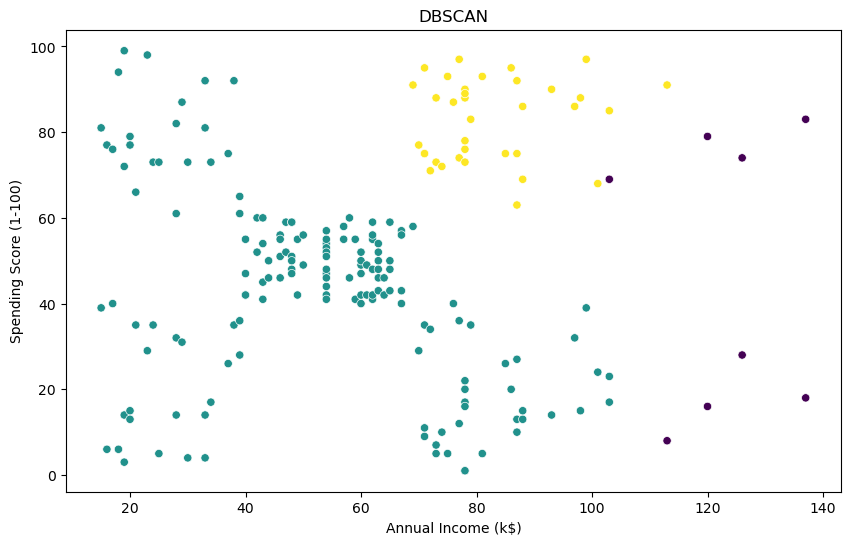

In [48]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=df['Annual Income (k$)'], y=df['Spending Score (1-100)'], c=df['cluster'])
plt.title('DBSCAN')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.show()